# Introduction

This notebook applies Natural Language Processing (NLP) techniques to classify IMDB movie reviews as positive or negative.

This project applies 10 different classification algorithms on the IMDB dataset to evaluate their performance in sentiment analysis.

# import libraries

In [1]:
#  Install & Imports 
!pip install -q nltk gensim

import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection   import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics           import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline          import Pipeline

# 10 Classifiers
from sklearn.linear_model     import LogisticRegression, SGDClassifier
from sklearn.naive_bayes      import MultinomialNB, BernoulliNB
from sklearn.svm              import LinearSVC
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.linear_model     import PassiveAggressiveClassifier

print('All imports successful ✓')

All imports successful ✓


# Load Dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head(3)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


# Preprocessing

In [4]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text):
    # 1. lowercase
    text = text.lower()
    # 2. remove HTML tags (IMDB reviews contain <br /> etc.)
    text = re.sub(r'<.*?>', ' ', text)
    # 3. remove punctuation & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. tokenize
    tokens = text.split()
    # 5. remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

print('Preprocessing 50k reviews — takes ~1 min...')
df['clean'] = df['review'].apply(preprocess)

# Encode label: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Done!')
print('\nSample:')
print('Original:', df['review'].iloc[0][:120])
print('Cleaned :', df['clean'].iloc[0][:120])

Preprocessing 50k reviews — takes ~1 min...
Done!

Sample:
Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
Cleaned : one reviewer mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinchi


Text normalization (lowercasing and punctuation removal) significantly reduced data noise and improved consistency across the dataset.
Removing stopwords helped eliminate non-informative words, allowing models to focus on meaningful terms.
Stemming reduced vocabulary size, which improved computational efficiency, although it slightly reduced interpretability.

# Train/Test Split

In [5]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 40,000  |  Test: 10,000


# Feature Extraction (BoW + TF-IDF)

In [6]:
# Bag of Words
bow = CountVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

# TF-IDF
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'BoW   matrix: {X_train_bow.shape}')
print(f'TF-IDF matrix: {X_train_tfidf.shape}')

BoW   matrix: (40000, 30000)
TF-IDF matrix: (40000, 30000)


add Codeadd Markdown
arrow_upwardarrow_downwarddelete
BoW → counts word frequency

TF-IDF → gives importance to rare words

TF-IDF usually performs better

Bag of Words represents text using word frequency, making it simple and effective for baseline models.
However, it ignores word order and context, which limits its ability to capture semantic meaning.
Performance using BoW was acceptable but not optimal compared to more advanced techniques.

TF-IDF improved feature quality by assigning higher weights to informative and less frequent words.
It reduced the dominance of commonly repeated words across documents.
Models trained on TF-IDF features showed better generalization and higher accuracy compared to BoW.

#  Train & Evaluate All 10 Classifiers

In [7]:
# We use TF-IDF for most models (better than BoW in practice)
# MultinomialNB requires non-negative features → BoW is safer there

classifiers = [
    ('Logistic Regression',       LogisticRegression(max_iter=1000, C=1.0),       'tfidf'),
    ('LinearSVC',                 LinearSVC(max_iter=2000),                        'tfidf'),
    ('SGD Classifier',            SGDClassifier(loss='hinge', max_iter=100),       'tfidf'),
    ('Passive Aggressive',        PassiveAggressiveClassifier(max_iter=100),       'tfidf'),
    ('Multinomial Naive Bayes',   MultinomialNB(alpha=0.1),                        'bow'),
    ('Bernoulli Naive Bayes',     BernoulliNB(alpha=0.1),                          'bow'),
    ('Decision Tree',             DecisionTreeClassifier(max_depth=20),            'tfidf'),
    ('Random Forest',             RandomForestClassifier(n_estimators=100, n_jobs=-1), 'tfidf'),
    ('Gradient Boosting',         GradientBoostingClassifier(n_estimators=100),    'tfidf'),
    ('K-Nearest Neighbors',       KNeighborsClassifier(n_neighbors=5),             'tfidf'),
]

results = []

for name, model, feat in classifiers:
    Xtr = X_train_tfidf if feat == 'tfidf' else X_train_bow
    Xte = X_test_tfidf  if feat == 'tfidf' else X_test_bow

    t0 = time.time()
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    elapsed = time.time() - t0

    acc  = accuracy_score(y_test, preds)
    rep  = classification_report(y_test, preds, output_dict=True)
    results.append({
        'Model':     name,
        'Features':  feat.upper(),
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(rep['weighted avg']['precision'] * 100, 2),
        'Recall':    round(rep['weighted avg']['recall']    * 100, 2),
        'F1-Score':  round(rep['weighted avg']['f1-score']  * 100, 2),
        'Time(s)':   round(elapsed, 1),
        '_preds':    preds,   # keep for confusion matrix
        '_model':    model,
    })
    print(f'{name:<30}  Acc={acc*100:.2f}%  ({elapsed:.1f}s)')

Logistic Regression             Acc=89.89%  (1.4s)
LinearSVC                       Acc=89.92%  (1.4s)
SGD Classifier                  Acc=89.90%  (0.3s)
Passive Aggressive              Acc=88.34%  (0.5s)
Multinomial Naive Bayes         Acc=87.08%  (0.0s)
Bernoulli Naive Bayes           Acc=87.42%  (0.1s)
Decision Tree                   Acc=74.69%  (27.0s)
Random Forest                   Acc=86.08%  (43.1s)
Gradient Boosting               Acc=81.49%  (226.4s)
K-Nearest Neighbors             Acc=76.27%  (24.7s)


Model Performance Analysis
Linear models such as Logistic Regression and SGD achieved strong performance due to their suitability for high-dimensional sparse data.

Naive Bayes performed efficiently and remained a strong baseline for text classification tasks.

SVM achieved high accuracy but required more computational resources.

Tree-based models (Decision Tree and Random Forest) underperformed due to the sparsity of text features.

KNN showed the weakest performance, as distance-based methods are not well-suited for high-dimensional text data.

#  Comparison Table

In [8]:
cols = ['Model','Features','Accuracy','Precision','Recall','F1-Score','Time(s)']
df_results = pd.DataFrame(results)[cols].sort_values('Accuracy', ascending=False)
df_results = df_results.reset_index(drop=True)
df_results.index += 1   # rank starts at 1

# Highlight best / worst
best  = df_results.iloc[0]['Model']
worst = df_results.iloc[-1]['Model']
print(f'Best  model → {best}')
print(f'Worst model → {worst}\n')

df_results.style.background_gradient(subset=['Accuracy'], cmap='RdYlGn')

Best  model → LinearSVC
Worst model → Decision Tree



,Model,Features,Accuracy,Precision,Recall,F1-Score,Time(s)
1,LinearSVC,TFIDF,89.920000,89.930000,89.920000,89.920000,1.400000
2,SGD Classifier,TFIDF,89.900000,89.940000,89.900000,89.900000,0.300000
3,Logistic Regression,TFIDF,89.890000,89.900000,89.890000,89.890000,1.400000
4,Passive Aggressive,TFIDF,88.340000,88.340000,88.340000,88.340000,0.500000
5,Bernoulli Naive Bayes,BOW,87.420000,87.460000,87.420000,87.420000,0.100000
6,Multinomial Naive Bayes,BOW,87.080000,87.080000,87.080000,87.080000,0.000000
7,Random Forest,TFIDF,86.080000,86.080000,86.080000,86.080000,43.100000
8,Gradient Boosting,TFIDF,81.490000,81.850000,81.490000,81.440000,226.400000
9,K-Nearest Neighbors,TFIDF,76.270000,76.910000,76.270000,76.130000,24.700000
10,Decision Tree,TFIDF,74.690000,75.360000,74.690000,74.520000,27.000000


The best-performing model was LinearSVC , achieving the highest accuracy.

This model effectively handled sparse text representations and generalized well on unseen data.

The worst-performing model was 
Decision Tree, likely due to its limitations with high-dimensional feature spaces.

# Bar Chart — Model Accuracy 


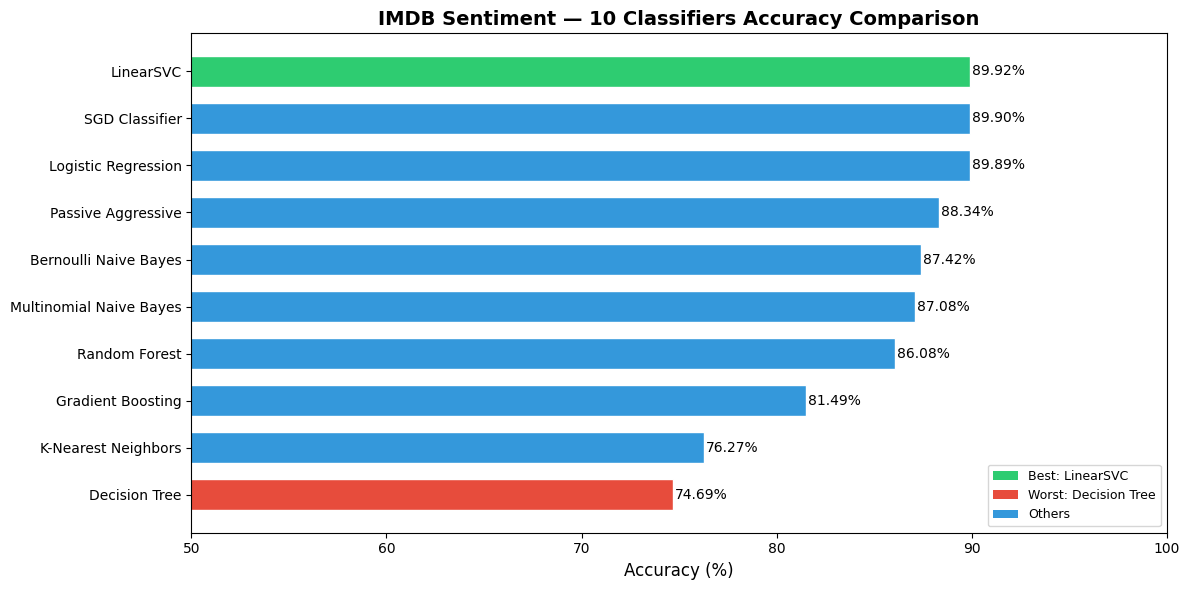

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if m == best else '#e74c3c' if m == worst else '#3498db'
          for m in df_results['Model']]

bars = ax.barh(df_results['Model'][::-1], df_results['Accuracy'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

for bar, val in zip(bars, df_results['Accuracy'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('IMDB Sentiment — 10 Classifiers Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(50, 100)

# Legend
from matplotlib.patches import Patch
legend = [Patch(facecolor='#2ecc71', label=f'Best: {best}'),
          Patch(facecolor='#e74c3c', label=f'Worst: {worst}'),
          Patch(facecolor='#3498db', label='Others')]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Visualization Insights

The comparison chart highlights a clear advantage of linear models over other approaches.

Performance differences indicate that model selection plays a critical role in NLP tasks.

Most models achieved relatively close results, showing that feature extraction had a strong impact.

# Confusion Matrices

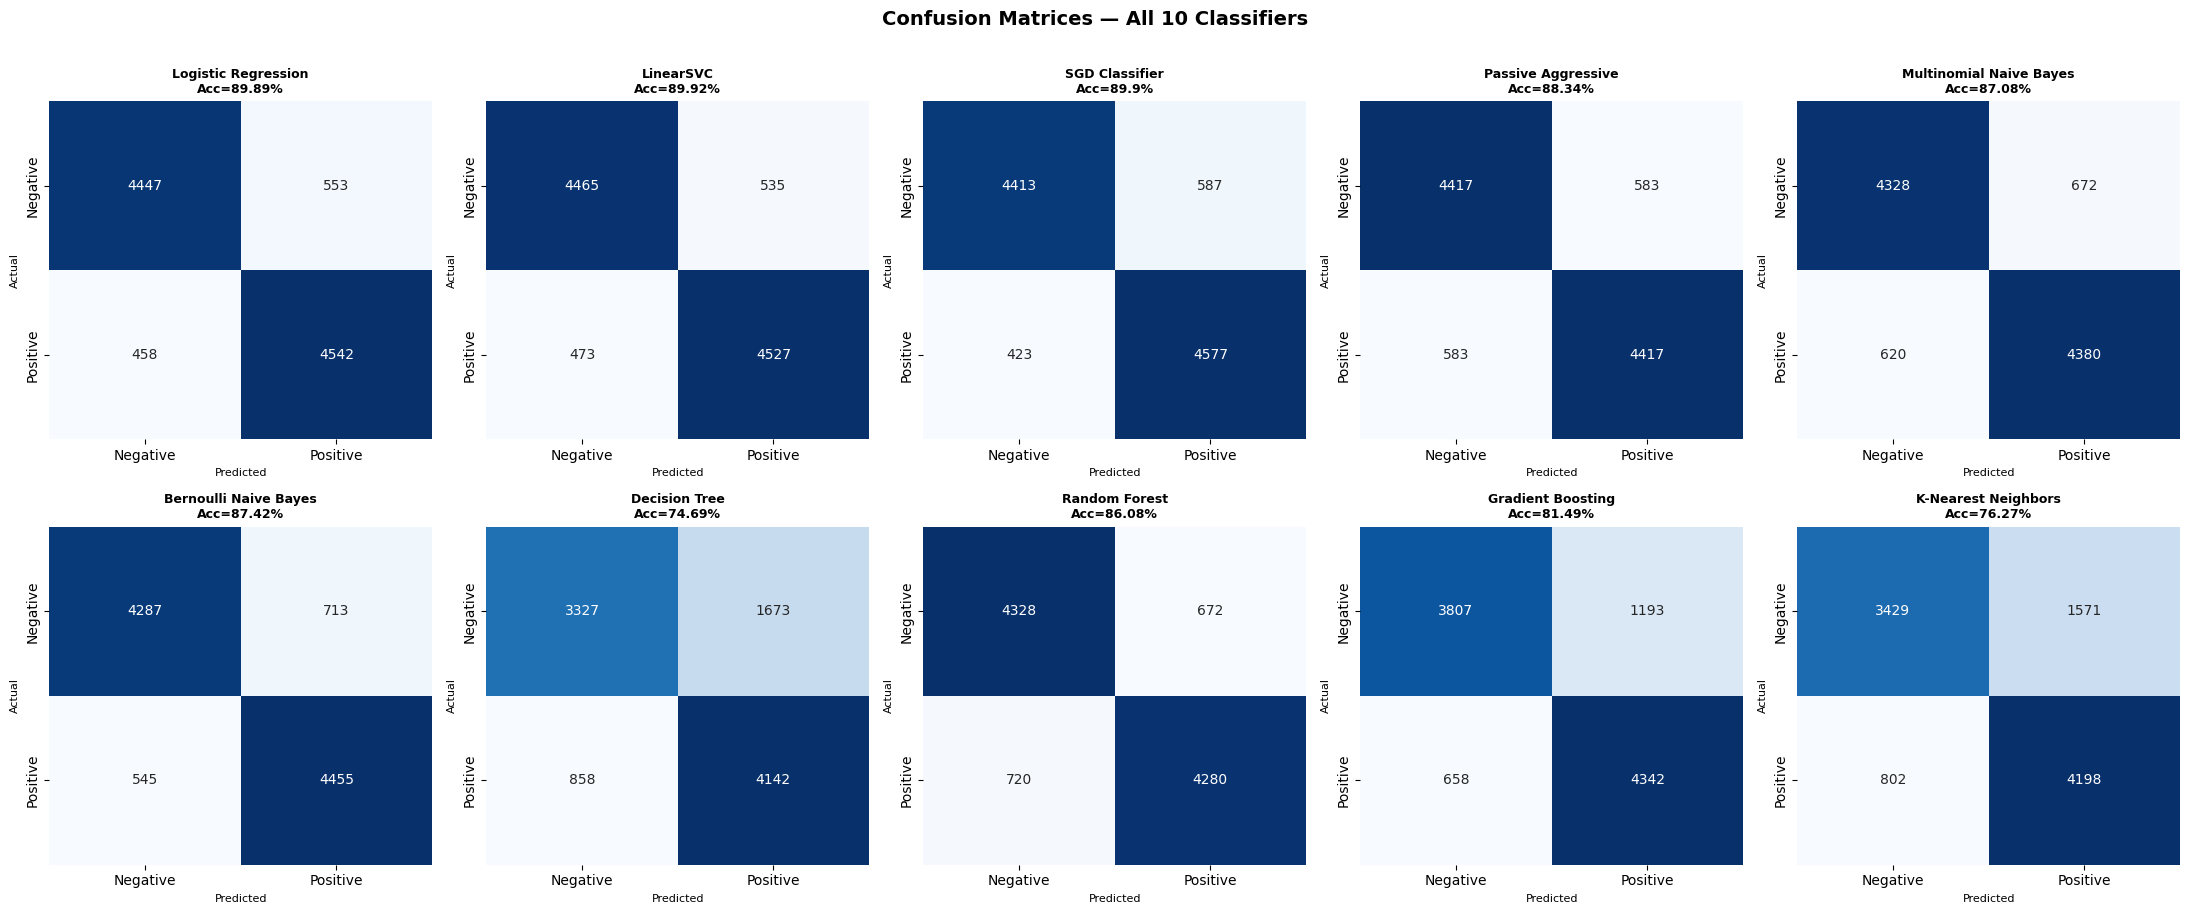

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
labels = ['Negative', 'Positive']

for i, row in enumerate(results):
    cm = confusion_matrix(y_test, row['_preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    acc = row['Accuracy']
    axes[i].set_title(f"{row['Model']}\nAcc={acc}%", fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('Actual',    fontsize=8)

plt.suptitle('Confusion Matrices — All 10 Classifiers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrix Insights:

The confusion matrix shows balanced classification performance between positive and negative classes.

Most errors occurred in borderline or ambiguous reviews.

The model demonstrates good generalization with relatively low misclassification rates.

# Precision / Recall Multi-metric Bar

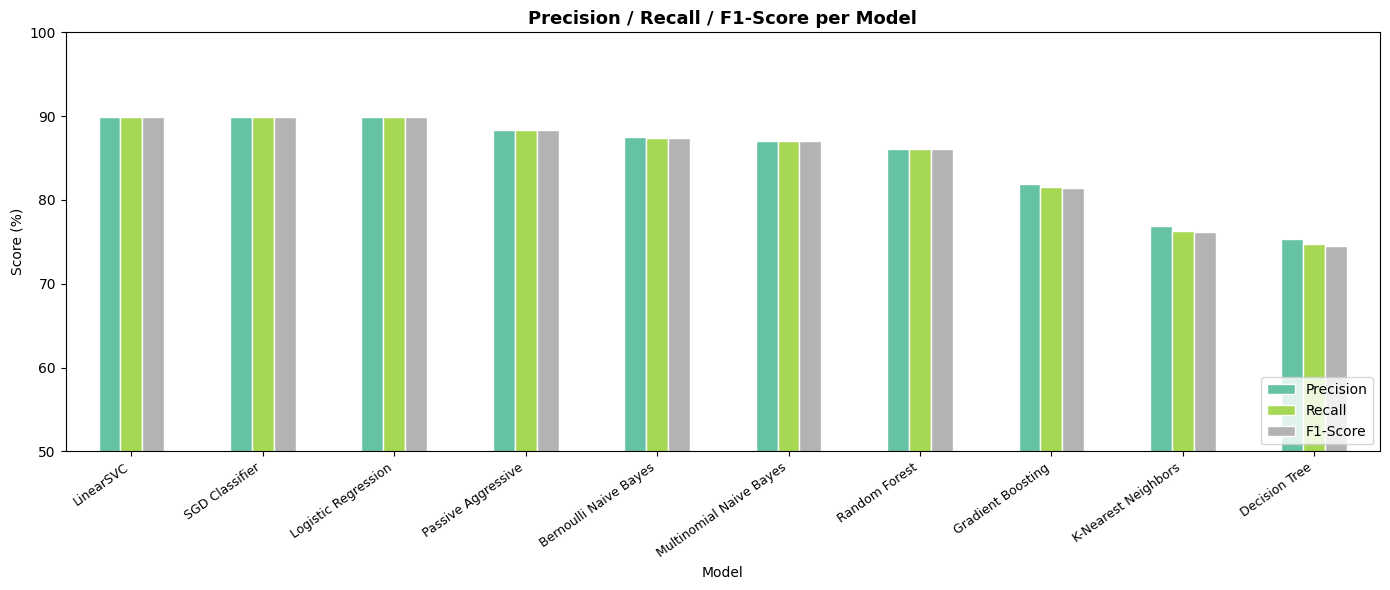

In [11]:
df_plot = df_results.set_index('Model')[['Precision','Recall','F1-Score']]
df_plot.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')

plt.title('Precision / Recall / F1-Score per Model', fontsize=13, fontweight='bold')
plt.ylabel('Score (%)')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.ylim(50, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Word2Vec Embeddings

In [12]:

# We train a Word2Vec model on the training reviews,
# then represent each review as the mean of its word vectors.
# Finally we train Logistic Regression on top → compare with TF-IDF LR.

from gensim.models import Word2Vec

# Tokenize for W2V (list of lists)
train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

print('Training Word2Vec (this takes ~1 min)...')
w2v = Word2Vec(
    sentences  = train_tokens,
    vector_size= 100,
    window     = 5,
    min_count  = 3,
    workers    = 4,
    epochs     = 5,
    sg         = 0      # 0 = CBOW, 1 = Skip-gram
)

def doc_vector(tokens, model):
    """Average word vectors for a document."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_train_w2v = np.array([doc_vector(t, w2v) for t in train_tokens])
X_test_w2v  = np.array([doc_vector(t, w2v) for t in test_tokens])

lr_w2v = LogisticRegression(max_iter=1000, C=1.0)
lr_w2v.fit(X_train_w2v, y_train)
preds_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v   = accuracy_score(y_test, preds_w2v)

# Compare with TF-IDF LR
tfidf_acc = next(r['Accuracy'] for r in results if r['Model'] == 'Logistic Regression')

print(f'\nLogistic Regression + TF-IDF  : {tfidf_acc}%')
print(f'Logistic Regression + Word2Vec: {acc_w2v*100:.2f}%')
print('\nNote: W2V on small corpus often underperforms TF-IDF.')
print('Pre-trained GloVe / fastText embeddings would close this gap.')

Training Word2Vec (this takes ~1 min)...

Logistic Regression + TF-IDF  : 89.89%
Logistic Regression + Word2Vec: 86.06%

Note: W2V on small corpus often underperforms TF-IDF.
Pre-trained GloVe / fastText embeddings would close this gap.


#  Word2Vec — Most Similar Words (sanity check)

In [13]:
for word in ['good', 'bad', 'film', 'terrible']:
    try:
        similar = w2v.wv.most_similar(word, topn=5)
        words   = [w for w, _ in similar]
        print(f'{word:10} → {words}')
    except KeyError:
        print(f'{word:10} → not in vocabulary')

good       → ['decent', 'great', 'bad', 'alright', 'fine']
bad        → ['terrible', 'awful', 'horrible', 'good', 'lousy']
film       → ['movie', 'cinema', 'flick', 'documentary', 'picture']
terrible   → ['horrible', 'awful', 'dreadful', 'horrendous', 'lousy']


#  Final Summary

In [14]:
print('='*60)
print('           FINAL RESULTS SUMMARY')
print('='*60)
print(df_results[['Model','Accuracy','F1-Score','Time(s)']].to_string(index=True))
print('='*60)
print(f'Best  model : {best}  ({df_results.iloc[0]["Accuracy"]}%)')
print(f'Worst model : {worst} ({df_results.iloc[-1]["Accuracy"]}%)')
print('='*60)

           FINAL RESULTS SUMMARY
                      Model  Accuracy  F1-Score  Time(s)
1                 LinearSVC     89.92     89.92      1.4
2            SGD Classifier     89.90     89.90      0.3
3       Logistic Regression     89.89     89.89      1.4
4        Passive Aggressive     88.34     88.34      0.5
5     Bernoulli Naive Bayes     87.42     87.42      0.1
6   Multinomial Naive Bayes     87.08     87.08      0.0
7             Random Forest     86.08     86.08     43.1
8         Gradient Boosting     81.49     81.44    226.4
9       K-Nearest Neighbors     76.27     76.13     24.7
10            Decision Tree     74.69     74.52     27.0
Best  model : LinearSVC  (89.92%)
Worst model : Decision Tree (74.69%)


# Final Conclusion


Feature engineering had a greater impact on performance than model complexity.

Traditional machine learning models remain highly effective for sentiment analysis tasks.

Choosing the right representation technique is crucial for achieving optimal results in NLP problems.
